In [6]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Section 20 - Convolutional Network Visualization"

import os
print("📂 Current directory:", os.getcwd())
!apt install tree -y
!tree -L 2 -a --dirsfirst

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Section 20 - Convolutional Network Visualization
📂 Current directory: /content/drive/MyDrive/Section 20 - Convolutional Network Visualization
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tree is already the newest version (2.0.2-1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
.
├── dog.jpg
├── imagenet_class_index.json
└── main_Section20.ipynb

0 directories, 3 files


In [8]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd
import imageio, json
from PIL import Image

import torch, torch.nn as nn, torchvision
from torchvision import transforms, utils

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# I. Image preprocessing and feeding into the model



## 1. Image processing

In [10]:
transform = transforms.Compose([transforms.Resize((224,224)),
                                transforms.ToTensor(),
                                transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])])

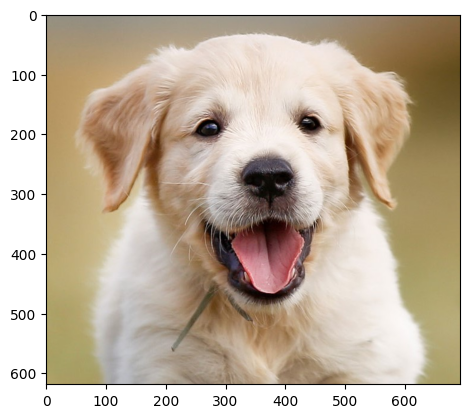

In [17]:
image = Image.open('./dog.jpg')
plt.imshow(image)

In [18]:
image = transform(image).unsqueeze(0).to(device)

In [19]:
print(image.shape)

torch.Size([1, 3, 224, 224])


## 2. Model definition

In [14]:
from torchvision.models import vgg16, VGG16_Weights
vgg = vgg16(weights=VGG16_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 64.0MB/s]


## 3. Feeding into the model

In [29]:
output = vgg(image)
print(output.shape)
output = output.squeeze(0)
print(output.shape)

torch.Size([1, 1000])
torch.Size([1000])


In [30]:
index = output.max(0)
values, indices = index
indices = indices.item()
print(indices)

207


In [31]:
with open('./imagenet_class_index.json', 'r') as f: labels = json.load(f)
label = labels[str(indices)][1]
print(label)

golden_retriever


# II. Visualize the feature maps

## 1. List of layer

In [38]:
module_list = list(vgg.features.modules())

In [49]:
module_list = list(vgg.features.modules())

print("Original structure: \n",module_list[0])
print("1st element: \n",module_list[1])
print("2nd element: \n",module_list[2])

Original structure: 
 Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv

## 2. Visualize

In [50]:
outputs = []
names = []

for layer in module_list[1:]:
    image = layer(image)
    outputs.append(image)
    names.append(str(layer))

In [51]:
for feature_map in outputs:
    print(feature_map.shape)

torch.Size([1, 64, 224, 224])
torch.Size([1, 64, 224, 224])
torch.Size([1, 64, 224, 224])
torch.Size([1, 64, 224, 224])
torch.Size([1, 64, 112, 112])
torch.Size([1, 128, 112, 112])
torch.Size([1, 128, 112, 112])
torch.Size([1, 128, 112, 112])
torch.Size([1, 128, 112, 112])
torch.Size([1, 128, 56, 56])
torch.Size([1, 256, 56, 56])
torch.Size([1, 256, 56, 56])
torch.Size([1, 256, 56, 56])
torch.Size([1, 256, 56, 56])
torch.Size([1, 256, 56, 56])
torch.Size([1, 256, 56, 56])
torch.Size([1, 256, 28, 28])
torch.Size([1, 512, 28, 28])
torch.Size([1, 512, 28, 28])
torch.Size([1, 512, 28, 28])
torch.Size([1, 512, 28, 28])
torch.Size([1, 512, 28, 28])
torch.Size([1, 512, 28, 28])
torch.Size([1, 512, 14, 14])
torch.Size([1, 512, 14, 14])
torch.Size([1, 512, 14, 14])
torch.Size([1, 512, 14, 14])
torch.Size([1, 512, 14, 14])
torch.Size([1, 512, 14, 14])
torch.Size([1, 512, 14, 14])
torch.Size([1, 512, 7, 7])


In [54]:
processed = []

for feature_map in outputs:
    feature_map = feature_map.squeeze(0)
    gray_scaled = torch.sum(feature_map, dim = 0)
    gray_scaled = gray_scaled / feature_map.shape[0]

    processed.append(gray_scaled.data.cpu().numpy())

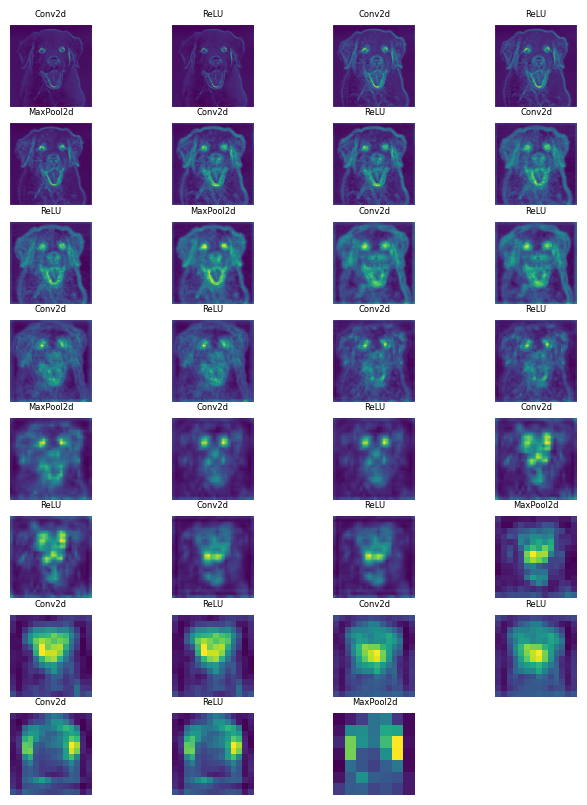

In [62]:
fig = plt.figure(figsize=(8, 10))

for i in range(len(processed)):
    a = fig.add_subplot(8, 4, i+1)
    a.imshow(processed[i])
    a.axis('off')
    a.set_title(names[i].split('(')[0], fontsize=6)

fig.savefig('feature_maps.png', bbox_inches='tight')
plt.show()
plt.close(fig)